# Deep Learning Assignment 1 Training Notebook Part 1
---
###### Author : Joel Quadras (D22125093)
###### Part 1: Music Genre Prediction Task

## Data Preprocessing

### Import Libraries and Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import gdown
import os,glob
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
import ast
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from keras.layers import Concatenate, Dense, LSTM, Input,GRU, concatenate,Dropout,LeakyReLU,SimpleRNN,Reshape
from tensorflow.keras.layers import LSTM, Dense, Embedding, Dropout, Input,Bidirectional
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import one_hot
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from keras.layers.convolutional import Conv1D
from keras.layers.convolutional import Conv2D
from keras.layers.convolutional import MaxPooling1D
from keras.layers import Flatten
from keras.models import Model
import joblib
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import SVC
from tensorflow.keras.layers import SimpleRNN, BatchNormalization, LeakyReLU, Flatten, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, BatchNormalization, LeakyReLU, Flatten, Dense
from tensorflow.keras.models import Sequential

###Loading google drive as Shareable link so that we can accesses the dataset and files

In [ ]:
#!pip install gdown

In [ ]:
data_url = "https://drive.google.com/drive/folders/1mrXxH6cFy3yUFYsXoYHLhNI0QevCvpn4?usp=sharing"

In [ ]:
gdown.download_folder (data_url, quiet=True, use_cookies=False)

['/content/original_dataset/combined_dataset.csv',
 '/content/original_dataset/Glove_model_weights/glove_cnn_lstm_model/glove_cnn_lstm_model_history.pkl',
 '/content/original_dataset/Glove_model_weights/glove_cnn_lstm_model/glove_cnn_lstm_model.h5',
 '/content/original_dataset/Glove_model_weights/glove_cnn_model/glove_cnn_model_history.pkl',
 '/content/original_dataset/Glove_model_weights/glove_cnn_model/glove_cnn_model.h5',
 '/content/original_dataset/Glove_model_weights/multi_layer_lstm_model/glove_multi_layer_lstm_history.pkl',
 '/content/original_dataset/Glove_model_weights/multi_layer_lstm_model/glove_multi_layer_lstm_model.h5',
 '/content/original_dataset/Glove_model_weights/simpleRNN_glove_model/glove_rnn_history.pkl',
 '/content/original_dataset/Glove_model_weights/simpleRNN_glove_model/simpleRNN_glove_model.h5',
 '/content/original_dataset/Glove_model_weights/single_layer_lstm_model/glove_single_layer_lstm_history.pkl',
 '/content/original_dataset/Glove_model_weights/single_la

### Train Data Preprocessing

In [ ]:
#Loading data
df_full_train = pd.read_csv("/content/original_dataset/train.csv")

In [ ]:
# Cleaning the texts
import re
import nltk
from nltk.corpus import stopwords            ## it will check stop words present in data
from nltk.stem.porter import PorterStemmer   ## it will use for stemmming the words
from nltk.stem import WordNetLemmatizer
#lemmer=WordNetLemmatizer()
#import gensim
from string import punctuation
from gensim.corpora import Dictionary
from nltk.tokenize import word_tokenize

In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
df_full_train['Lyrics'].head()

0    It starts with pain, followed by hate\nFueled ...
1    Freedom!\nAlone again again alone\nPatiently w...
2    Biting the hand that feeds you, lying to the v...
3    You say you know just who I am\nBut you can't ...
4    My heart is beating faster can't control these...
Name: Lyrics, dtype: object

In [ ]:
# Save the preprocessed dataset to a CSV file
#df_full_train.to_csv("/content/drive/MyDrive/Data_Saved/preprocessed_dataset.csv", index=False)

In [ ]:
df_full_train.shape

(290183, 5)

In [ ]:
#Just taking the sample of train dataset

df = df_full_train.sample(frac=0.05, random_state=42)

In [ ]:
#after the sample data
df.shape

(14509, 5)

In [ ]:
#checking Top 5 rows

df.head()

,Artist,Song,Genre,Language,Lyrics
180931,big daddy,hold on,Rock,en,I know there's pain\nWhy do lock yourself up i...
269990,aqualung,if i fall,Rock,en,swept away\nby the wonder of it all\nso amazed...
275612,george ezra,benjamin twine,Indie,en,"Let me tell you about my best friend, he got h..."
195014,we came as romans,what i wished i never had,Metal,en,Don't catch me at the wrong time\nOr you will ...
26829,jimmy eat world,softer (she's perfect),Rock,en,She's perfect in her own way.\nSmoke rings ris...


In [ ]:
#checking Normal info
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 14509 entries, 180931 to 103143
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Artist    14509 non-null  object
 1   Song      14509 non-null  object
 2   Genre     14509 non-null  object
 3   Language  14509 non-null  object
 4   Lyrics    14506 non-null  object
dtypes: object(5)
memory usage: 680.1+ KB


In [ ]:
#checking wether the dataset had null values in the dataset
df.isnull().sum()

Artist      0
Song        0
Genre       0
Language    0
Lyrics      3
dtype: int64

In [ ]:
#we have some null values in the dataset which are song, language and Lyrics
#so we are going to remove the null values from dataset
df = df.dropna()

In [ ]:
#still checking if we have any null values
df.isnull().sum()

Artist      0
Song        0
Genre       0
Language    0
Lyrics      0
dtype: int64

In [ ]:
#We are just copying the data as backup in the environment
data = df.copy()

In [ ]:
print(data["Artist"].unique())

['big daddy' 'aqualung' 'george ezra' ... 'before their eyes'
 'the streets' 'the tellers']


In [ ]:
data.nunique()

Artist       3868
Song        13219
Genre          10
Language       26
Lyrics      14262
dtype: int64

In [ ]:
data['Artist'].nunique()

3868

In [ ]:
# Checking for duplicate rows
duplicate_rows = data[data.duplicated()]

In [ ]:
print("Number of duplicate rows:", len(duplicate_rows))


Number of duplicate rows: 80


In [ ]:
#Chicking for visual conformation whether they are really duplicate
duplicate_rows.head()

,Artist,Song,Genre,Language,Lyrics
84223,nicki minaj,"only (feat. drake, lil wayne, chris brown)",Pop,en,"[Nicki Minaj]\nYo, I never fucked Wayne, I nev..."
29313,kerli,don't look at me,Pop,en,What is it we're fighting for?\nAnd when we'll...
71547,beyonce,hymn for the weekend,Pop,en,"Oh, angels sent from up above\nYou know you ma..."
111190,luan santana,chuva de arroz,Pop,pt,"Não mudei de cidade, nem de telefone\nSó escol..."
115541,one direction,little things,Pop,en,Your hand fits in mine\nLike it's made just fo...


In [ ]:
#Just copying the complete data
data_cleaned = data.copy()

In [ ]:
#checking the shape
data_cleaned.shape

(14506, 5)

In [ ]:
#checking again for null values
data_cleaned.isnull().sum()

Artist      0
Song        0
Genre       0
Language    0
Lyrics      0
dtype: int64

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense

from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt


In [ ]:
# Spliting data into train, validation, and using stratifyed sampling

train_data, val_data = train_test_split(data_cleaned, test_size=0.2, random_state=42, stratify =data_cleaned["Genre"])


### Test Data Preprocessing

In [ ]:
# Loading the separate test dataset
df_full_test_data = pd.read_csv("/content/original_dataset/test.csv")

In [ ]:
df_full_test_data.head()

,Song,Song year,Artist,Genre,Lyrics,Track_id
0,craftsmanship,2005,buck-65,Hip-Hop,Most folks spend their days daydreaming of fin...,8294
1,come-on-out,2012,the-elwins,Indie,Take your cold hands and put them on my face\n...,21621
2,riot,2013,bullet-for-my-valentine,Metal,Are you ready it's time for war\nWe'll break d...,3301
3,that-s-what-girls-do,2007,dream-street,Pop,You ask me why I change the color of my hair\n...,2773
4,believe-in-a-dollar,2012,cassidy,Hip-Hop,Do you believe in magic in a young girl's hear...,16797


In [ ]:
df_full_test_data.shape

(7935, 6)

In [ ]:
#Just taking the sample of test dataset
test_data = df_full_test_data.sample(frac=0.2, random_state=42)

In [ ]:
test_data.head()

,Song,Song year,Artist,Genre,Lyrics,Track_id
1172,false-projection,2007,carrier-flux,Metal,what crime is worth the signature - right\nwha...,4836
1883,i-had-a-dream-i-was-falling,2006,deee-lite,Electronic,Through a Hole in the Ozone Layer\nDreams\nOh ...,23765
6635,someday,2006,chicago,Rock,Would you look around you now\nAnd tell me wha...,2319
5835,rodeo-cowboy,2007,chris-ledoux,Country,I meet her in Wyoming at the Cheyenne rodeo\nJ...,14647
4898,nil-se-n-la,2014,celtic-woman,Folk,Nil Se'n La\nChuaigh mÃ© isteach i dteach arÃ©...,7190


In [ ]:
test_data.shape

(1587, 6)

### Preprocessing the Train, test and validation data to get it ready for model input.

Output variable

In [ ]:
# Converting genre labels to one-hot encoding as it is a multiclass classification

#Converting first genre labels to integers using label encoding
label_encoder = LabelEncoder()
train_data["Genre"] = label_encoder.fit_transform(train_data["Genre"])
val_data["Genre"] = label_encoder.transform(val_data["Genre"])
test_data["Genre"] = label_encoder.transform(test_data["Genre"])


In [ ]:
#Taking Number of class count using legnth fuction
num_classes = len(label_encoder.classes_)

In [ ]:
# Converting secondly genre labels to one-hot encoding
y_train = tf.keras.utils.to_categorical(train_data["Genre"], num_classes)
y_val = tf.keras.utils.to_categorical(val_data["Genre"], num_classes)
y_test = tf.keras.utils.to_categorical(test_data["Genre"], num_classes)

Input variable

In [ ]:
# Creating TF-IDF text vectorizer

#When we run population data we can keep 10000 or more
#For now we are keeping 5000 for model building and computational purpose

max_features = 5000  # we can adjust as needed

tfidf_vectorizer = TfidfVectorizer(max_features=max_features)

In [ ]:
# Fitting and transforming the text data
#training set
X_train_tfidf = tfidf_vectorizer.fit_transform(train_data["Lyrics"])
#validation set
X_val_tfidf = tfidf_vectorizer.transform(val_data["Lyrics"])

#Test_dataset
X_test_tfidf = tfidf_vectorizer.transform(test_data["Lyrics"])


In [ ]:
# Converting sparse matrices to dense arrays
X_train_tfidf_dense = X_train_tfidf.toarray()
X_val_tfidf_dense = X_val_tfidf.toarray()
X_test_tfidf_dense = X_test_tfidf.toarray()

Saving the train test and validation data.

In [ ]:
#Data saving for further use in future

np.savez('/content/drive/MyDrive/original_dataset/Task_1_model_weights/train_and_test_data.npz',
         X_test=X_test_tfidf_dense, y_test=y_test,X_train=X_train_tfidf_dense,y_train=y_train, X_val = X_val_tfidf_dense, y_val= y_val)

## RNN Variants

### RNN

In [ ]:
from tensorflow.keras.layers import SimpleRNN, BatchNormalization, LeakyReLU, Flatten, Dense
from tensorflow.keras.models import Sequential

In [ ]:
from tensorflow.keras.layers import LSTM, BatchNormalization, LeakyReLU, Flatten, Dense
from tensorflow.keras.models import Sequential

In [ ]:
# Defining the Vanilla(Basic) RNN model

def build_rnn_model():
    model_simple_rnn = Sequential()
    model_simple_rnn.add(Embedding(input_dim=max_features, output_dim=128, input_length=X_train_tfidf.shape[1]))
    model_simple_rnn.add(SimpleRNN(128, return_sequences=False))
    model_simple_rnn.add(BatchNormalization())
    model_simple_rnn.add(LeakyReLU(alpha=0.01))
    model_simple_rnn.add(Flatten())
    model_simple_rnn.add(Dense(num_classes, activation='softmax'))
    #return model_simple_rnn
    print(model_simple_rnn.summary())

    return model_simple_rnn

"# Defining the LSTM model\n#def build_lstm_model():\n    model_lstm = Sequential()\n    model_lstm.add(Embedding(input_dim=max_features, output_dim=128, input_length=X_train_tfidf.shape[1]))\n    model_lstm.add(LSTM(128, return_sequences=True))\n    model_lstm.add(LSTM(64, return_sequences=False))\n    model_lstm.add(BatchNormalization())\n    model_lstm.add(LeakyReLU(alpha=0.01))\n    model_lstm.add(Flatten())\n    model_lstm.add(Dense(num_classes, activation='softmax'))\n    print(model_lstm.summary())\n    return model_lstm\n"

In [ ]:
#Building the RNN model using above fuction

rnn_model = build_rnn_model()
rnn_model.compile(optimizer = "adam", loss="categorical_crossentropy", metrics=["accuracy"])


Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_6 (Embedding)     (None, 5000, 128)         640000    
                                                                 
 simple_rnn_2 (SimpleRNN)    (None, 128)               32896     
                                                                 
 batch_normalization_6 (Batc  (None, 128)              512       
 hNormalization)                                                 
                                                                 
 leaky_re_lu_6 (LeakyReLU)   (None, 128)               0         
                                                                 
 flatten_6 (Flatten)         (None, 128)               0         
                                                                 
 dense_6 (Dense)             (None, 10)                1290      
                                                      

In [ ]:
# Defining early stopping criteria
early_stop = EarlyStopping(monitor='val_loss', patience=2)

# Training the models with dense arrays
batch_size = 32  # Adjust as needed
epochs = 10  # Adjust as needed
# Building and compiling the models within the strategy scope and using categorical_crossentropy as loss fucntion


Printing simpleRNN Epochs


In [ ]:
# Increase batch size
batch_size = 32  # Adjust as needed

# Implement a learning rate schedule
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(initial_learning_rate=0.01, decay_steps=10000, decay_rate=0.9)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

print("Printing simpleRNN Epochs")
# Train the model with updated parameters
rnn_model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])
rnn_history = rnn_model.fit(X_train_tfidf_dense, y_train, validation_data=(X_val_tfidf_dense, y_val), epochs=epochs, batch_size=batch_size, callbacks=[early_stop])


Epoch 1/10
363/363 [==============================] - 1823s 5s/step - loss: 1.4631 - accuracy: 0.4109 - val_loss: 4.2773 - val_accuracy: 0.0476
Epoch 2/10
363/363 [==============================] - 1804s 5s/step - loss: 1.4411 - accuracy: 0.4166 - val_loss: 1.9664 - val_accuracy: 0.4218
Epoch 3/10
363/363 [==============================] - 1799s 5s/step - loss: 1.4391 - accuracy: 0.4096 - val_loss: 1.7163 - val_accuracy: 0.4218
Epoch 4/10
363/363 [==============================] - 1794s 5s/step - loss: 1.4389 - accuracy: 0.4166 - val_loss: 7.0033 - val_accuracy: 0.0076
Epoch 5/10
363/363 [==============================] - 1799s 5s/step - loss: 1.4368 - accuracy: 0.4169 - val_loss: 19.7591 - val_accuracy: 0.0072


Model Saving


In [ ]:
# Save the trained models
rnn_model.save('/content/drive/MyDrive/original_dataset/Task_1_model_weights/rnn_model/rnn_model.h5')

In [ ]:
from keras.models import Sequential, load_model
import pickle

with open('/content/drive/MyDrive/original_dataset/Task_1_model_weights/rnn_model/rnn_history.pkl', 'wb') as f:
    pickle.dump(rnn_history, f)

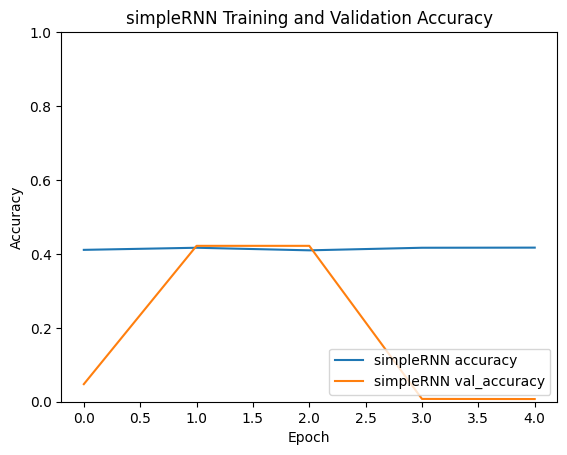

In [ ]:
# Ploting training and validation metrics as graphs
def plot_history(history, model_name):
    plt.plot(history.history['accuracy'], label=f'{model_name} accuracy')
    plt.plot(history.history['val_accuracy'], label = f'{model_name} val_accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim([0, 1])
    plt.legend(loc='lower right')
    plt.title(f'{model_name} Training and Validation Accuracy')
    plt.show()

plot_history(rnn_history, 'simpleRNN')
#plot_history(lstm_history, 'LSTM')

###Single layer LSTM implementation and a multi-layer LSTM implementation

In [ ]:
# Building and compile the models

def build_single_layer_lstm_model():
    model_lstm = Sequential()
    model_lstm.add(Embedding(input_dim=max_features, output_dim=128, input_length=X_train_tfidf.shape[1]))
    model_lstm.add(LSTM(128, return_sequences=False))
    model_lstm.add(Dropout(0.5))  # Add dropout layer with a dropout rate of 0.5
    model_lstm.add(BatchNormalization())
    model_lstm.add(LeakyReLU(alpha=0.01))
    model_lstm.add(Flatten())
    model_lstm.add(Dense(num_classes, activation='softmax'))
    print(model_lstm.summary())

    return model_lstm

def build_multi_layer_lstm_model():
    model_lstm = Sequential()
    model_lstm.add(Embedding(input_dim=max_features, output_dim=128, input_length=X_train_tfidf.shape[1]))
    model_lstm.add(LSTM(128, return_sequences=True))
    model_lstm.add(Dropout(0.5))  # Add dropout layer with a dropout rate of 0.5
    model_lstm.add(LSTM(128, return_sequences=True))
    model_lstm.add(Dropout(0.5))  # Add dropout layer with a dropout rate of 0.5
    model_lstm.add(LSTM(128, return_sequences=False))
    model_lstm.add(Dropout(0.5))  # Add dropout layer with a dropout rate of 0.5
    model_lstm.add(BatchNormalization())
    model_lstm.add(LeakyReLU(alpha=0.01))
    model_lstm.add(Flatten())
    model_lstm.add(Dense(num_classes, activation='softmax'))
    print(model_lstm.summary())
    return model_lstm

In [ ]:
# Building and compiling the models within the strategy scope and using categorical_crossentropy as loss fucntion

single_layer_lstm_model = build_single_layer_lstm_model()
single_layer_lstm_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

multi_layer_lstm_model = build_multi_layer_lstm_model()
multi_layer_lstm_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])


NameError: ignored

In [ ]:
# Defining early stopping criteria
early_stop = EarlyStopping(monitor='val_loss', patience=2)


# Train the models
batch_size = 32
epochs = 10
print("Printing single layer lstm epochs")
single_layer_lstm_history = single_layer_lstm_model.fit(X_train_tfidf_dense, y_train,
                                                        validation_data=(X_val_tfidf_dense, y_val), epochs=epochs, batch_size=batch_size, callbacks=[early_stop])
print("Printing multilayer layer lstm epochs")

multi_layer_lstm_history = multi_layer_lstm_model.fit(X_train_tfidf_dense, y_train,
                                                      validation_data=(X_val_tfidf_dense, y_val), epochs=epochs, batch_size=batch_size, callbacks=[early_stop])


Printing single layer lstm epochs
Epoch 1/10
363/363 [==============================] - 58s 152ms/step - loss: 1.5101 - accuracy: 0.3897 - val_loss: 1.9277 - val_accuracy: 0.3673
Epoch 2/10
363/363 [==============================] - 54s 149ms/step - loss: 1.4676 - accuracy: 0.4041 - val_loss: 1.8896 - val_accuracy: 0.4218
Epoch 3/10
363/363 [==============================] - 54s 149ms/step - loss: 1.4570 - accuracy: 0.4119 - val_loss: 1.5411 - val_accuracy: 0.4218
Epoch 4/10
363/363 [==============================] - 54s 149ms/step - loss: 1.4513 - accuracy: 0.4093 - val_loss: 1.5805 - val_accuracy: 0.3673
Epoch 5/10
363/363 [==============================] - 54s 149ms/step - loss: 1.4507 - accuracy: 0.4118 - val_loss: 1.6391 - val_accuracy: 0.4218
Printing multilayer layer lstm epochs
Epoch 1/10
363/363 [==============================] - 168s 448ms/step - loss: 1.5219 - accuracy: 0.3971 - val_loss: 1.9795 - val_accuracy: 0.4218
Epoch 2/10
363/363 [==============================] - 161

Model saving For LSTM's

In [ ]:
# Save the trained models
single_layer_lstm_model.save("/content/drive/MyDrive/original_dataset/LSTM_Weights_task_1/single_layer_lstm_model/single_layer_lstm_model.h5")


In [ ]:
from keras.models import Sequential, load_model
import pickle
#saving model
with open('/content/drive/MyDrive/original_dataset/LSTM_Weights_task_1/single_layer_lstm_model/single_layer_lstm_history.pkl', 'wb') as f:
    pickle.dump(single_layer_lstm_history, f)

In [ ]:
#Model saving
multi_layer_lstm_model.save('/content/drive/MyDrive/original_dataset/LSTM_Weights_task_1/multi_layer_lstm_model/multi_layer_lstm_model.h5')


In [ ]:
from keras.models import Sequential, load_model
import pickle
#saving model
with open('/content/drive/MyDrive/original_dataset/LSTM_Weights_task_1/multi_layer_lstm_model/multi_layer_lstm_history.pkl', 'wb') as f:
    pickle.dump(multi_layer_lstm_history, f)

Ploting

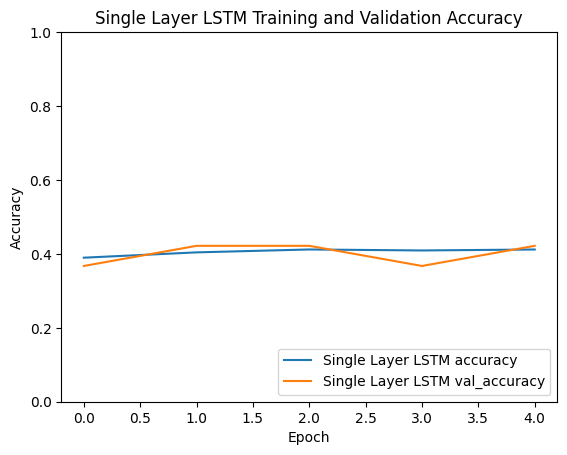

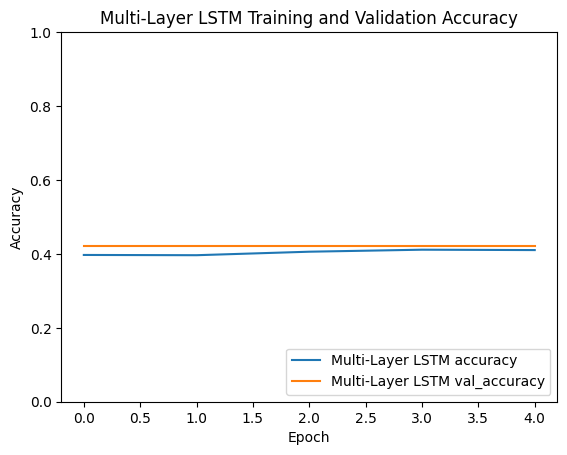

In [ ]:
# Plot training and validation accuracy as graphs
def plot_history(history, model_name):
    plt.plot(history.history['accuracy'], label=f'{model_name} accuracy')
    plt.plot(history.history['val_accuracy'], label = f'{model_name} val_accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim([0, 1])
    plt.legend(loc='lower right')
    plt.title(f'{model_name} Training and Validation Accuracy')
    plt.show()

plot_history(single_layer_lstm_history, 'Single Layer LSTM')
plot_history(multi_layer_lstm_history, 'Multi-Layer LSTM')

#CNN for Text Classification

---

In [ ]:
# Creating TF-IDF text vectorizer

#When we run population data we can keep 10000 or more
#For now we are keeping 5000 for model building and computational purpose

max_features = 5000  # we can adjust as needed

tfidf_vectorizer = TfidfVectorizer(max_features=max_features)

In [ ]:
# Fitting and transforming the text data
#training set
X_train_tfidf = tfidf_vectorizer.fit_transform(train_data["Lyrics"])
#validation set
X_val_tfidf = tfidf_vectorizer.transform(val_data["Lyrics"])

#Test_dataset
X_test_tfidf = tfidf_vectorizer.transform(test_data["Lyrics"])

In [ ]:
# Converting secondly genre labels to one-hot encoding
y_train = tf.keras.utils.to_categorical(train_data["Genre"], num_classes)
y_val = tf.keras.utils.to_categorical(val_data["Genre"], num_classes)
y_test = tf.keras.utils.to_categorical(test_data["Genre"], num_classes)

In [ ]:
# Converting sparse matrices to dense arrays
X_train_tfidf_dense = X_train_tfidf.toarray()
X_val_tfidf_dense = X_val_tfidf.toarray()
X_test_tfidf_dense = X_test_tfidf.toarray()

In [ ]:
#Data saving for further use in future

np.savez('/content/drive/MyDrive/original_dataset/Task_1_model_weights/cnn_lstm_train_and_test_data/train_and_test_data.npz',
         X_test=X_test_tfidf_dense, y_test=y_test,X_train=X_train_tfidf_dense,y_train=y_train, X_val = X_val_tfidf_dense, y_val= y_val)

In [ ]:
from keras.layers import Conv1D, GlobalMaxPooling1D


### CNN

In [ ]:
# Defining the CNN model here we are using specially Conv1D

def build_cnn_model():
    model_cnn = Sequential()
    model_cnn.add(Embedding(input_dim=max_features, output_dim=128, input_length=X_train_tfidf.shape[1]))
    model_cnn.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
    model_cnn.add(Conv1D(filters=64, kernel_size=4, activation='relu'))
    model_cnn.add(Conv1D(filters=64, kernel_size=5, activation='relu'))
    model_cnn.add(GlobalMaxPooling1D())
    model_cnn.add(Dense(128, activation='relu'))
    model_cnn.add(Dense(num_classes, activation='softmax'))
    #model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    print(model_cnn.summary())
    return model_cnn


###CNN as an Additional Layer Before LSTM

In [ ]:
def build_cnn_lstm_model():
    model_cnn_lstm = Sequential()
    model_cnn_lstm.add(Embedding(input_dim=max_features, output_dim=128, input_length=X_train_tfidf.shape[1]))
    model_cnn_lstm.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
    model_cnn_lstm.add(Conv1D(filters=64, kernel_size=4, activation='relu'))
    model_cnn_lstm.add(Conv1D(filters=64, kernel_size=5, activation='relu'))
    model_cnn_lstm.add(GlobalMaxPooling1D())
    model_cnn_lstm.add(Reshape((1, -1)))  # Flatten the output for LSTM
    model_cnn_lstm.add(LSTM(128, return_sequences=False))
    model_cnn_lstm.add(Dense(num_classes, activation='softmax'))
    #model_cnn_lstm.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    print(model_cnn_lstm.summary())
    return model_cnn_lstm

In [ ]:
# Create a MirroredStrategy for distributed training (if multiple GPUs available)
#strategy = tf.distribute.MirroredStrategy()

In [ ]:
#with strategy.scope():

cnn_model = build_cnn_model()
cnn_model.compile(optimizer = "adam", loss="categorical_crossentropy", metrics=["accuracy"])

cnn_lstm_model = build_cnn_lstm_model()
cnn_lstm_model.compile(optimizer = "adam", loss="categorical_crossentropy", metrics=["accuracy"])

cnn_model.summary()
cnn_lstm_model.summary()

Model: "sequential_22"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_22 (Embedding)    (None, 5000, 128)         640000    
                                                                 
 conv1d_36 (Conv1D)          (None, 4998, 64)          24640     
                                                                 
 conv1d_37 (Conv1D)          (None, 4995, 64)          16448     
                                                                 
 conv1d_38 (Conv1D)          (None, 4991, 64)          20544     
                                                                 
 global_max_pooling1d_12 (Gl  (None, 64)               0         
 obalMaxPooling1D)                                               
                                                                 
 dense_27 (Dense)            (None, 128)               8320      
                                                     

In [ ]:
# Defining early stopping criteria
early_stop = EarlyStopping(monitor='val_loss', patience=2)

# Training the models with dense arrays
# Train the models using distributed training (with larger batch size)
batch_size = 32  # Adjust as needed
epochs = 10  # Adjust as needed
# Building and compiling the models within the strategy scope and using categorical_crossentropy as loss fucntion


print("Printing CNN Epochs")
cnn_history = cnn_model.fit(X_train_tfidf_dense, y_train, validation_data=(X_val_tfidf_dense, y_val), epochs=epochs, batch_size=batch_size, callbacks=[early_stop])

print("Printing CNN_LSTM Epochs")
cnn_lstm_history = cnn_lstm_model.fit(X_train_tfidf_dense, y_train, validation_data=(X_val_tfidf_dense, y_val), epochs=epochs, batch_size=batch_size, callbacks=[early_stop])


Printing CNN Epochs
Epoch 1/10
363/363 [==============================] - 17s 41ms/step - loss: 1.4718 - accuracy: 0.4087 - val_loss: 1.4416 - val_accuracy: 0.3691
Epoch 2/10
363/363 [==============================] - 14s 39ms/step - loss: 1.4430 - accuracy: 0.4141 - val_loss: 1.4535 - val_accuracy: 0.4218
Epoch 3/10
363/363 [==============================] - 14s 40ms/step - loss: 1.4402 - accuracy: 0.4050 - val_loss: 1.4366 - val_accuracy: 0.4218
Epoch 4/10
363/363 [==============================] - 14s 40ms/step - loss: 1.4377 - accuracy: 0.4147 - val_loss: 1.4583 - val_accuracy: 0.4218
Epoch 5/10
363/363 [==============================] - 15s 40ms/step - loss: 1.4378 - accuracy: 0.4141 - val_loss: 1.4373 - val_accuracy: 0.4218
Printing CNN_LSTM Epochs
Epoch 1/10
363/363 [==============================] - 19s 43ms/step - loss: 1.4669 - accuracy: 0.4140 - val_loss: 1.4338 - val_accuracy: 0.4218
Epoch 2/10
363/363 [==============================] - 15s 41ms/step - loss: 1.4378 - accura

In [ ]:
# Save the trained models
cnn_model.save('/content/drive/MyDrive/original_dataset/Task_1_model_weights/cnn_model/cnn_model.h5')

In [ ]:
from keras.models import Sequential, load_model
import pickle
#Saving model history in pickle format
with open('/content/drive/MyDrive/original_dataset/Task_1_model_weights/cnn_model/cnn_history.pkl', 'wb') as f:
    pickle.dump(cnn_history, f)

In [ ]:
#saving model
cnn_lstm_model.save('/content/drive/MyDrive/original_dataset/Task_1_model_weights/cnn_lstm_model/cnn_lstm_model.h5')

In [ ]:
from keras.models import Sequential, load_model
import pickle

with open('/content/drive/MyDrive/original_dataset/Task_1_model_weights/cnn_lstm_model/cnn_lstm_model.pkl', 'wb') as f:
    pickle.dump(cnn_lstm_history, f)

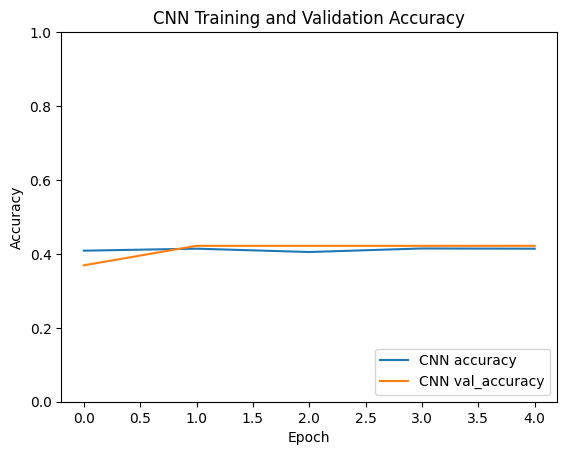

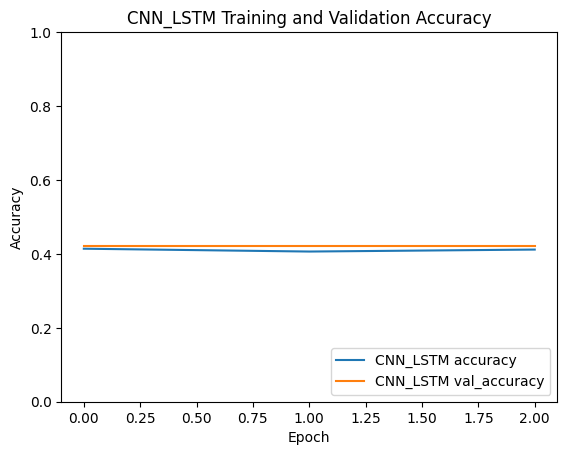

In [ ]:
# Ploting training and validation metrics as graphs
def plot_history(history, model_name):
    plt.plot(history.history['accuracy'], label=f'{model_name} accuracy')
    plt.plot(history.history['val_accuracy'], label = f'{model_name} val_accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim([0, 1])
    plt.legend(loc='lower right')
    plt.title(f'{model_name} Training and Validation Accuracy')
    plt.show()

plot_history(cnn_history, 'CNN')
plot_history(cnn_lstm_history, 'CNN_LSTM')

#Embeddings

---



##Embeddings learned on the fly to any VS pre-trained word embedding

In [ ]:
from keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=max_features)  # num_words should match max_features
tokenizer.fit_on_texts(train_data["Lyrics"])  # Assuming train_data contains your text data

word_index = tokenizer.word_index

In [ ]:
#print(word_index)

In [ ]:
# Load the pre-trained GloVe word vectors
embeddings_index = {}
with open("/content/original_dataset/glove.6B.100d.txt", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = coefs

# Prepare an embedding matrix for your vocabulary
num_words = min(max_features, len(word_index) + 1)  # Ensure it doesn't exceed max_features
embedding_dim = 100  # Size of the GloVe vectors

embedding_matrix = np.zeros((num_words, embedding_dim))

for word, i in word_index.items():
    if i >= num_words:
        continue
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector



###RNN with Glove Pre-trained Embeddings

In [ ]:
def build_rnn_model():
    model_simple_rnn = Sequential()
    model_simple_rnn.add(Embedding(input_dim=num_words, output_dim=embedding_dim, weights=[embedding_matrix], input_length=X_train_tfidf_dense.shape[1], trainable=False))  # Set trainable=False to keep the pre-trained weights fixed
    model_simple_rnn.add(SimpleRNN(128, return_sequences=False))
    model_simple_rnn.add(BatchNormalization())
    model_simple_rnn.add(LeakyReLU(alpha=0.01))
    model_simple_rnn.add(Flatten())
    model_simple_rnn.add(Dense(num_classes, activation='softmax'))
    #return model_simple_rnn
    print(model_simple_rnn.summary())

    return model_simple_rnn


###LSTM and Multi-Layer LSTM with Glove Pre-trained Embeddings

In [ ]:
# Building and compile the models

def build_single_layer_lstm_model():
    model_lstm = Sequential()
    model_lstm.add(Embedding(input_dim=num_words, output_dim=embedding_dim, weights=[embedding_matrix], input_length=X_train_tfidf_dense.shape[1], trainable=False))  # Set trainable=False to keep the pre-trained weights fixed
    model_lstm.add(LSTM(128, return_sequences=False))
    #model_lstm.add(Dropout(0.5))  # Add dropout layer with a dropout rate of 0.5
    model_lstm.add(BatchNormalization())
    model_lstm.add(LeakyReLU(alpha=0.01))
    model_lstm.add(Flatten())
    model_lstm.add(Dense(num_classes, activation='softmax'))
    print(model_lstm.summary())

    return model_lstm

def build_multi_layer_lstm_model():
    model_lstm = Sequential()
    model_lstm.add(Embedding(input_dim=num_words, output_dim=embedding_dim, weights=[embedding_matrix], input_length=X_train_tfidf_dense.shape[1], trainable=False))  # Set trainable=False to keep the pre-trained weights fixed
    model_lstm.add(LSTM(128, return_sequences=True))
    #model_lstm.add(Dropout(0.5))  # Add dropout layer with a dropout rate of 0.5
    model_lstm.add(LSTM(64, return_sequences=True))
    #model_lstm.add(Dropout(0.5))  # Add dropout layer with a dropout rate of 0.5
    model_lstm.add(LSTM(64, return_sequences=False))
    #model_lstm.add(Dropout(0.5))  # Add dropout layer with a dropout rate of 0.5
    model_lstm.add(BatchNormalization())
    model_lstm.add(LeakyReLU(alpha=0.01))
    model_lstm.add(Flatten())
    model_lstm.add(Dense(num_classes, activation='softmax'))
    print(model_lstm.summary())
    return model_lstm

In [ ]:
# Building and compiling the models within the strategy scope and using categorical_crossentropy as loss fucntion

simpleRNN_glove_model = build_rnn_model()
simpleRNN_glove_model.layers[0].set_weights([embedding_matrix])  # Set the pre-trained weights
simpleRNN_glove_model.layers[0].trainable = False  # Freeze the embedding layer
simpleRNN_glove_model.compile(optimizer = "adam", loss="categorical_crossentropy", metrics=["accuracy"])

glove_single_layer_lstm_model = build_single_layer_lstm_model()
glove_single_layer_lstm_model.layers[0].set_weights([embedding_matrix])  # Set the pre-trained weights
glove_single_layer_lstm_model.layers[0].trainable = False  # Freeze the embedding layer
glove_single_layer_lstm_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

glove_multi_layer_lstm_model = build_multi_layer_lstm_model()
glove_multi_layer_lstm_model.layers[0].set_weights([embedding_matrix])  # Set the pre-trained weights
glove_multi_layer_lstm_model.layers[0].trainable = False  # Freeze the embedding layer
glove_multi_layer_lstm_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])


Model: "sequential_15"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_15 (Embedding)    (None, 5000, 100)         500000    
                                                                 
 simple_rnn_3 (SimpleRNN)    (None, 128)               29312     
                                                                 
 batch_normalization_6 (Batc  (None, 128)              512       
 hNormalization)                                                 
                                                                 
 leaky_re_lu_6 (LeakyReLU)   (None, 128)               0         
                                                                 
 flatten_6 (Flatten)         (None, 128)               0         
                                                                 
 dense_18 (Dense)            (None, 10)                1290      
                                                     

In [ ]:
# Defining early stopping criteria
early_stop = EarlyStopping(monitor='val_loss', patience=2)


# Train the models
batch_size = 32
epochs = 10
print("Printing Glove simpleRNN Epochs")
glove_rnn_history = simpleRNN_glove_model.fit(X_train_tfidf_dense, y_train,
                            validation_data=(X_val_tfidf_dense, y_val), epochs=epochs, batch_size=batch_size, callbacks=[early_stop])

print("Printing Glove single layer lstm epochs")
glove_single_layer_lstm_history = glove_single_layer_lstm_model.fit(X_train_tfidf_dense, y_train,
                                                        validation_data=(X_val_tfidf_dense, y_val), epochs=epochs, batch_size=batch_size, callbacks=[early_stop])

print("Printing Glove multilayer layer lstm epochs")
glove_multi_layer_lstm_history = glove_multi_layer_lstm_model.fit(X_train_tfidf_dense, y_train,
                                                      validation_data=(X_val_tfidf_dense, y_val), epochs=epochs, batch_size=batch_size, callbacks=[early_stop])


Printing Glove simpleRNN Epochs
Epoch 1/10
363/363 [==============================] - 892s 2s/step - loss: 1.6014 - accuracy: 0.4203 - val_loss: 7.7327 - val_accuracy: 0.4218
Epoch 2/10
363/363 [==============================] - 878s 2s/step - loss: 1.4346 - accuracy: 0.4217 - val_loss: 1.7495 - val_accuracy: 0.4218
Epoch 3/10
363/363 [==============================] - 883s 2s/step - loss: 1.4328 - accuracy: 0.4217 - val_loss: 1.4323 - val_accuracy: 0.4218
Epoch 4/10
363/363 [==============================] - 896s 2s/step - loss: 1.4327 - accuracy: 0.4217 - val_loss: 1.4329 - val_accuracy: 0.4218
Epoch 5/10
363/363 [==============================] - 901s 2s/step - loss: 1.4328 - accuracy: 0.4193 - val_loss: 1.4320 - val_accuracy: 0.4218
Epoch 6/10
363/363 [==============================] - 888s 2s/step - loss: 1.4335 - accuracy: 0.4217 - val_loss: 1.4317 - val_accuracy: 0.4218
Epoch 7/10
363/363 [==============================] - 876s 2s/step - loss: 1.4330 - accuracy: 0.4190 - val_los

###Model saving which are trained on pre-trained Embedding

In [ ]:
#saving model
simpleRNN_glove_model.save('/content/drive/MyDrive/original_dataset/Glove_model_weights/simpleRNN_glove_model/simpleRNN_glove_model.h5')

glove_single_layer_lstm_model.save('/content/drive/MyDrive/original_dataset/Glove_model_weights/single_layer_lstm_model/glove_single_layer_lstm_model.h5')
glove_multi_layer_lstm_model.save('/content/drive/MyDrive/original_dataset/Glove_model_weights/multi_layer_lstm_model/glove_multi_layer_lstm_model.h5')

In [ ]:
from keras.models import Sequential, load_model
import pickle

#Saving Model history into pickle files
with open('/content/drive/MyDrive/original_dataset/Glove_model_weights/simpleRNN_glove_model/glove_rnn_history.pkl', 'wb') as f:
    pickle.dump(glove_rnn_history, f)

with open('/content/drive/MyDrive/original_dataset/Glove_model_weights/single_layer_lstm_model/glove_single_layer_lstm_history.pkl', 'wb') as f:
    pickle.dump(glove_single_layer_lstm_history, f)

with open('/content/drive/MyDrive/original_dataset/Glove_model_weights/multi_layer_lstm_model/glove_multi_layer_lstm_history.pkl', 'wb') as f:
    pickle.dump(glove_multi_layer_lstm_history, f)

Ploting

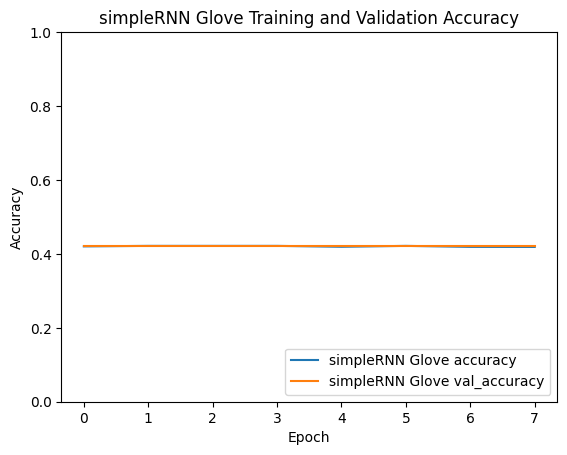

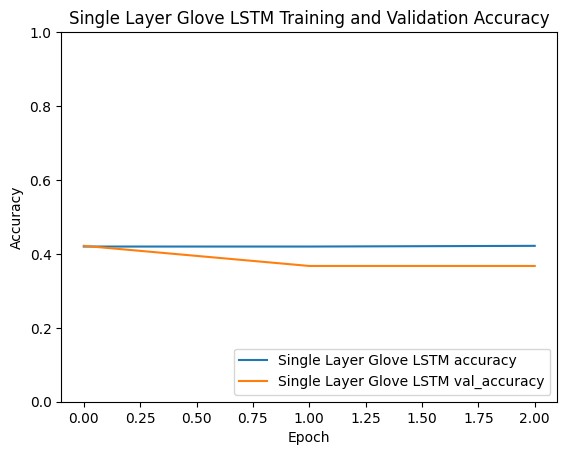

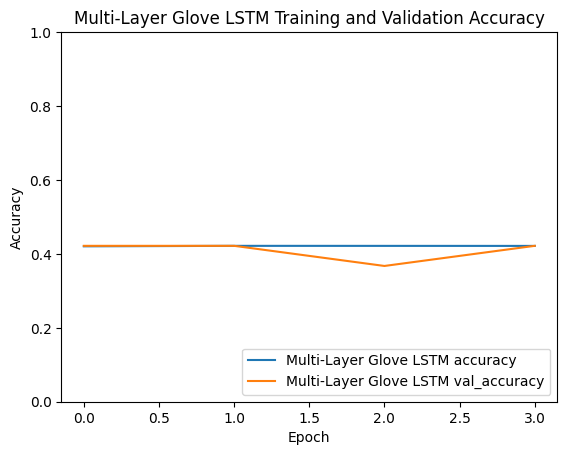

In [ ]:
# Ploting training and validation metrics as graphs
def plot_history(history, model_name):
    plt.plot(history.history['accuracy'], label=f'{model_name} accuracy')
    plt.plot(history.history['val_accuracy'], label = f'{model_name} val_accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim([0, 1])
    plt.legend(loc='lower right')
    plt.title(f'{model_name} Training and Validation Accuracy')
    plt.show()

plot_history(glove_rnn_history, 'simpleRNN Glove')
#plot_history(lstm_history, 'LSTM')
plot_history(glove_single_layer_lstm_history, 'Single Layer Glove LSTM')
plot_history(glove_multi_layer_lstm_history, 'Multi-Layer Glove LSTM')

#Embeddings for CNN and LSTM

---



##Embeddings learned on pre-trained word embedding

###CNN as an Alternative to LSTM:

In [ ]:
# Defining the CNN model here we are using specially Conv1D

def build_cnn_model():
    model_cnn = Sequential()
    model_cnn.add(Embedding(input_dim=max_features, output_dim=embedding_dim, weights=[embedding_matrix], input_length=X_train_tfidf_dense.shape[1], trainable=False))
    model_cnn.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
    model_cnn.add(Conv1D(filters=64, kernel_size=4, activation='relu'))
    model_cnn.add(Conv1D(filters=64, kernel_size=5, activation='relu'))
    model_cnn.add(GlobalMaxPooling1D())
    model_cnn.add(Dense(128, activation='relu'))
    model_cnn.add(Dense(num_classes, activation='softmax'))
    #model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    print(model_cnn.summary())

    return model_cnn

###CNN as an Additional Layer Before LSTM:

In [ ]:
# Building and compile the models CNN as an additional layer before LSTM

def build_cnn_lstm_model():
    model_cnn_lstm = Sequential()
    model_cnn_lstm.add(Embedding(input_dim=max_features, output_dim=embedding_dim, weights=[embedding_matrix], input_length=X_train_tfidf_dense.shape[1], trainable=False))
    model_cnn_lstm.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
    model_cnn_lstm.add(Conv1D(filters=64, kernel_size=4, activation='relu'))
    model_cnn_lstm.add(Conv1D(filters=64, kernel_size=5, activation='relu'))
    model_cnn_lstm.add(GlobalMaxPooling1D())
    model_cnn_lstm.add(Reshape((1, -1)))  # Flatten the output for LSTM
    model_cnn_lstm.add(LSTM(128, return_sequences=False))
    model_cnn_lstm.add(Dense(num_classes, activation='softmax'))
    #model_cnn_lstm.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    print(model_cnn_lstm.summary())
    return model_cnn_lstm

In [ ]:
# Building and compiling the models within the strategy scope and using categorical_crossentropy as loss fucntion

glove_cnn_model = build_cnn_model()
glove_cnn_model.layers[0].set_weights([embedding_matrix])  # Set the pre-trained weights
glove_cnn_model.layers[0].trainable = False  # Freeze the embedding layer
glove_cnn_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

glove_cnn_lstm_model = build_cnn_lstm_model()
glove_cnn_lstm_model.layers[0].set_weights([embedding_matrix])  # Set the pre-trained weights
glove_cnn_lstm_model.layers[0].trainable = False  # Freeze the embedding layer
glove_cnn_lstm_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])


Model: "sequential_20"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_20 (Embedding)    (None, 5000, 100)         500000    
                                                                 
 conv1d_30 (Conv1D)          (None, 4998, 64)          19264     
                                                                 
 conv1d_31 (Conv1D)          (None, 4995, 64)          16448     
                                                                 
 conv1d_32 (Conv1D)          (None, 4991, 64)          20544     
                                                                 
 global_max_pooling1d_10 (Gl  (None, 64)               0         
 obalMaxPooling1D)                                               
                                                                 
 dense_24 (Dense)            (None, 128)               8320      
                                                     

In [ ]:
# Defining early stopping criteria
early_stop = EarlyStopping(monitor='val_loss', patience=2)


# Train the models
batch_size = 32
epochs = 10
#print("Printing Glove simpleRNN Epochs")
#glove_rnn_history = simpleRNN_glove_model.fit(X_train_tfidf_dense, y_train, validation_data=(X_val_tfidf_dense, y_val), epochs=epochs, batch_size=batch_size, callbacks=[early_stop])

print("Printing Glove CNN epochs")
glove_cnn_model_history = glove_cnn_model.fit(X_train_tfidf_dense, y_train,
                                                        validation_data=(X_val_tfidf_dense, y_val), epochs=epochs, batch_size=batch_size, callbacks=[early_stop])

print("Printing Glove CNN_LSTM epochs")
glove_cnn_lstm_model_history = glove_cnn_lstm_model.fit(X_train_tfidf_dense, y_train,
                                                      validation_data=(X_val_tfidf_dense, y_val), epochs=epochs, batch_size=batch_size, callbacks=[early_stop])



Printing Glove CNN epochs
Epoch 1/10
363/363 [==============================] - 14s 33ms/step - loss: 1.5095 - accuracy: 0.4074 - val_loss: 1.4376 - val_accuracy: 0.4218
Epoch 2/10
363/363 [==============================] - 12s 32ms/step - loss: 1.4365 - accuracy: 0.4157 - val_loss: 1.4385 - val_accuracy: 0.4218
Epoch 3/10
363/363 [==============================] - 12s 32ms/step - loss: 1.4379 - accuracy: 0.4174 - val_loss: 1.4332 - val_accuracy: 0.4218
Epoch 4/10
363/363 [==============================] - 12s 32ms/step - loss: 1.4363 - accuracy: 0.4168 - val_loss: 1.4355 - val_accuracy: 0.4218
Epoch 5/10
363/363 [==============================] - 12s 32ms/step - loss: 1.4362 - accuracy: 0.4174 - val_loss: 1.4369 - val_accuracy: 0.4218
Printing Glove CNN_LSTM epochs
Epoch 1/10
363/363 [==============================] - 15s 35ms/step - loss: 1.5062 - accuracy: 0.4108 - val_loss: 1.4337 - val_accuracy: 0.4218
Epoch 2/10
363/363 [==============================] - 12s 33ms/step - loss: 1.4

In [ ]:
#saving model

glove_cnn_model.save('/content/drive/MyDrive/original_dataset/Glove_model_weights/glove_cnn_model/glove_cnn_model.h5')
glove_cnn_lstm_model.save('/content/drive/MyDrive/original_dataset/Glove_model_weights/glove_cnn_lstm_model/glove_cnn_lstm_model.h5')

In [ ]:
from keras.models import Sequential, load_model
import pickle
#Saving the models history in pickle format

#with open('/content/drive/MyDrive/original_dataset/Glove_model_weights/simpleRNN_glove_model/glove_rnn_history.pkl', 'wb') as f:
#    pickle.dump(glove_rnn_history, f)

with open('/content/drive/MyDrive/original_dataset/Glove_model_weights/glove_cnn_model/glove_cnn_model_history.pkl', 'wb') as f:
    pickle.dump(glove_cnn_model_history, f)

with open('/content/drive/MyDrive/original_dataset/Glove_model_weights/glove_cnn_lstm_model/glove_cnn_lstm_model_history.pkl', 'wb') as f:
    pickle.dump(glove_cnn_lstm_model_history, f)

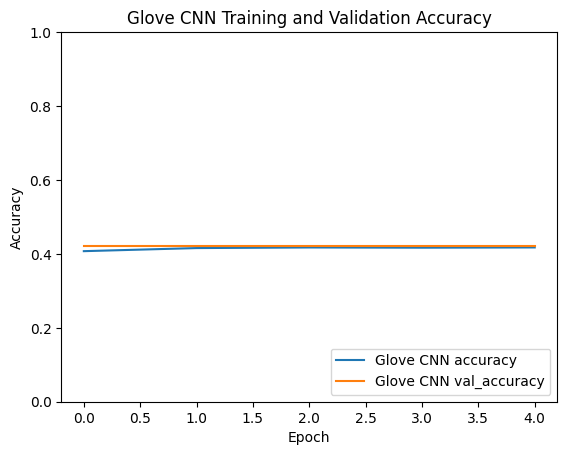

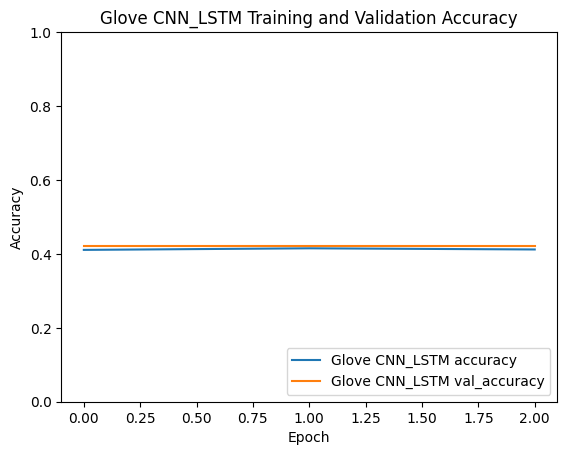

In [ ]:
# Ploting training and validation metrics as graphs
def plot_history(history, model_name):
    plt.plot(history.history['accuracy'], label=f'{model_name} accuracy')
    plt.plot(history.history['val_accuracy'], label = f'{model_name} val_accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim([0, 1])
    plt.legend(loc='lower right')
    plt.title(f'{model_name} Training and Validation Accuracy')
    plt.show()

plot_history(glove_cnn_model_history, 'Glove CNN')
plot_history(glove_cnn_lstm_model_history, 'Glove CNN_LSTM')